In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(10, 6))

print("All libraries imported successfully.")

All libraries imported successfully.


<Figure size 1000x600 with 0 Axes>

In [3]:
# loading the datasets
nav_df = pd.read_csv(r"C:\Users\austi\OneDrive\Desktop\Capstone_Project\data\processed\clean_nav_history.csv")

aum_df = pd.read_csv(r"C:\Users\austi\OneDrive\Desktop\Capstone_Project\data\raw\03_aum_by_fund_house.csv")

sip_df = pd.read_csv(r"C:\Users\austi\OneDrive\Desktop\Capstone_Project\data\raw\04_monthly_sip_inflows.csv")

category_df = pd.read_csv(r"C:\Users\austi\OneDrive\Desktop\Capstone_Project\data\raw\05_category_inflows.csv")

trans_df = pd.read_csv(r"C:\Users\austi\OneDrive\Desktop\Capstone_Project\data\processed\clean_investor_transactions.csv")

holding_df = pd.read_csv(r"C:\Users\austi\OneDrive\Desktop\Capstone_Project\data\raw\09_portfolio_holdings.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [4]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
# eda chart nav trend analysis

nav_df['date'] = pd.to_datetime(nav_df['date'])

daily_nav = nav_df.groupby('date')['nav'].mean().reset_index()

fig = px.line(daily_nav, x='date', y='nav', title='Average NAV Trend Over Time')
fig.show()

### Insights 1: NAV Trend Analysis

The average NAV across mutual fund schemes shows a steady upward trend from 2022 to 2026.

A strong growth phase is visible during 2023 and continues through 2025, indicating sustained market performance and investor confidence.

The highest average NAV values are observed in 2026.

In [13]:
pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
print(os.getcwd())

c:\Users\austi\OneDrive\Desktop\Capstone_Project\notebooks


In [7]:
fig.write_image("../reports/charts/nav_trend.png") 

In [8]:
# Now getting the AUM Growth Bar Chart
aum_df.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [9]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [10]:
# Creating the AUM Growth Bar Chart
# AUM Growth Analysis
aum_df['date'] = pd.to_datetime(aum_df['date'])

aum_df['year'] = aum_df['date'].dt.year

In [11]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [12]:
# Keep only years 2022 -2025
aum_filtererd = aum_df[aum_df['year'].isin([2022, 2023, 2024, 2025])]

# Creating grouped bar by fund house for each year 2022–2025. Highlight SBI at ₹12.5L Cr
fig = px.bar(aum_filtererd, x='year', y='aum_lakh_crore', color='fund_house', title='AUM Growth by Fund House (2022-2025)', barmode='group')
fig.show()

In [13]:
fig.write_image("../reports/charts/aum_growth.png")

### Insight 2: AUM Growth Analysis

Assets Under Management (AUM) increased consistently across major fund houses between 2022 and 2025.

SBI Mutual Fund maintained leadership in total AUM throughout the period, indicating strong market presence and investor trust.

Most fund houses demonstrated positive growth trends, reflecting increasing participation in mutual fund investments.

##### Now working on SIP Inflow Time-Series Analysis

In [14]:
sip_df.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [15]:
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [16]:
# Convert month column to datetime
sip_df['month'] = pd.to_datetime(sip_df['month'])

In [17]:
#  create sip trend line chart
fig = px.line(sip_df, x='month', y='sip_inflow_crore', title='Monthly SIP Inflows Over Time (2022-2025)', markers=True)

fig.show()

In [18]:
# Finding the Highest SIP Inflow
sip_df.loc[sip_df['sip_inflow_crore'].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [19]:
# now after confirming the highest SIP inflow, we can annotate it on the chart
fig = px.line(sip_df, x='month', y='sip_inflow_crore', title='Monthly SIP Inflows Over Time (2022-2025)', markers=True)

fig.add_annotation(x='2025-12-01', y = 31002, text ="all time high of ₹31,002 Cr in Dec 2025", showarrow=True, arrowhead=2)

fig.show()

In [21]:
fig.write_image("../reports/charts/sip_trend.png")

### Insight 3: SIP Inflow Trend Analysis

Monthly SIP inflows exhibited a strong upward trend between 2022 and 2025.

Investor participation increased steadily, resulting in higher recurring investment contributions through SIPs.

The highest SIP inflow of ₹31,002 Crore was recorded in December 2025, indicating strong retail investor confidence and continued growth in systematic investment plans.

In [23]:
# Next task : Category Inflow Heatmap

# reading the category_df columns
category_df.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [24]:
# Getting the first few rows of category_df
category_df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [31]:
# convert Month column to datetime
category_df['month'] = pd.to_datetime(category_df['month'])
category_df['month'] = category_df['month'].dt.strftime('%b-%Y')

In [34]:
# Heatmap requires data in matrix format
# Creating Pivot table for heatmap
heatmap_data = category_df.pivot(
    index='category',
    columns = 'month',
    values = 'net_inflow_crore'
    )

heatmap_data = heatmap_data.sort_index()

Text(145.72222222222223, 0.5, 'Fund Category')

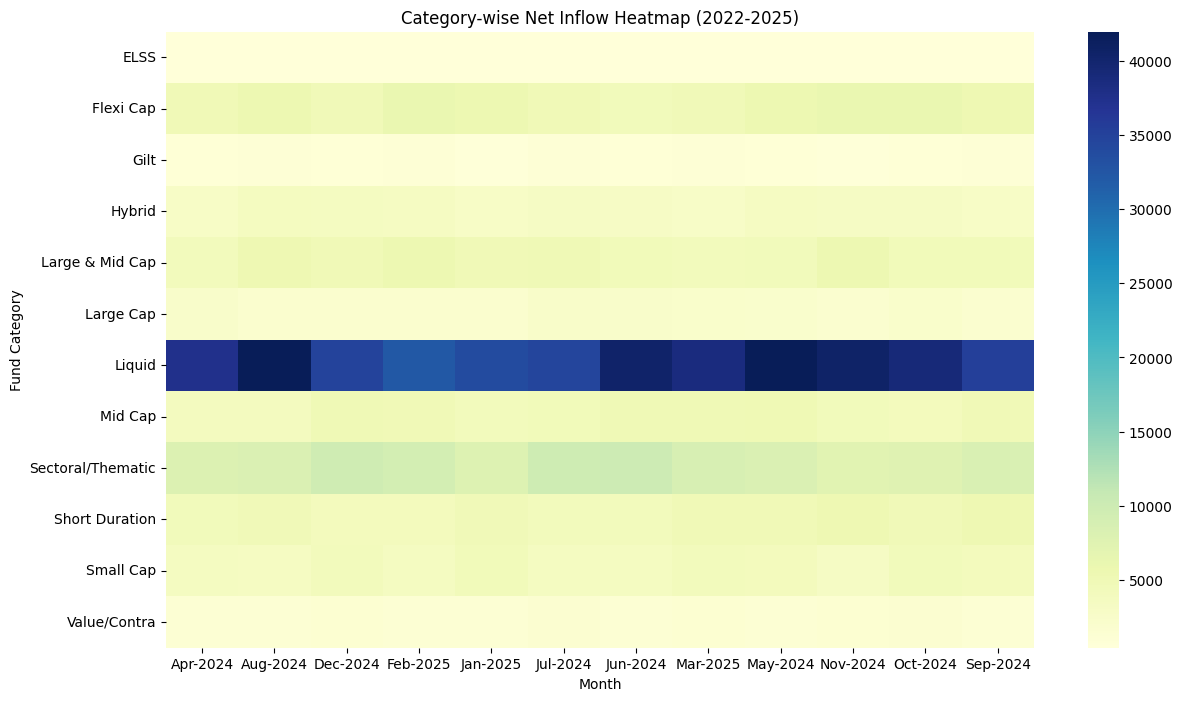

In [35]:
# Generating Heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)

plt.title('Category-wise Net Inflow Heatmap (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Fund Category')

In [39]:
fig.write_image("../reports/charts/category_heatmap.png")

plt.show()

### Insight 4: Category Inflow Analysis

Net inflows varied significantly across mutual fund categories over time.

Large Cap, Flexi Cap and Large & Mid Cap categories consistently attracted strong investor interest.

Certain categories experienced periods of weaker inflows, indicating changing investor preferences and market conditions.

The heatmap highlights clear concentration of investments in equity-oriented categories.

In [40]:
# Investor Demographics Analysis
# requires
# 1) Age Group Distribution Pie Chart
# 2) SIP Amount Box Plot by Age Group
# 3) Gender Split Chart
trans_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [41]:
trans_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [42]:
# Age Group Distribution Pie Chart
age_counts = trans_df['age_group'].value_counts()

fig = px.pie(
    values=age_counts.values, 
    names=age_counts.index, 
    title='Investor Age Group Distribution')
fig.show()

In [43]:
fig.write_image("../reports/charts/age_group_distribution.png")

### Insight 5: Age Group Distribution

The majority of investors belong to the working-age population segments, particularly the 26–35 and 36–45 age groups.

Young and middle-aged investors contribute significantly to mutual fund participation, indicating growing financial awareness and long-term wealth creation goals.

In [44]:
# SIP Amount Box Plot by Age Group
fig = px.box(
    trans_df, 
    x='age_group', 
    y='amount_inr', 
    title='Investment Amount Distribution by Age Group'
    ) 

fig.show()

In [45]:
fig.write_image("../reports/charts/sip_amount_boxplot.png")

### Insight 6: Investment Amount Analysis

Investment amounts vary across age groups, with older investors generally contributing larger investment values.

The box plot highlights the distribution, spread, and presence of high-value investors across demographic segments.

In [46]:
# Gender Split Chart
gender_counts = trans_df['gender'].value_counts()

fig = px.pie(
    values=gender_counts.values, 
    names=  gender_counts.index,
    title='Gender Distribution of Investors')

fig.show()

In [47]:
fig.write_image("../reports/charts/gender_distribution.png")

### Insight 7: Gender Distribution

Male investors currently represent a larger share of mutual fund participation compared to female investors.

However, participation from female investors remains significant, reflecting increasing financial inclusion and investment awareness.

In [50]:
# Geographic Distribution Analysis
trans_df['state'].nunique()
trans_df['state'].value_counts().head(10)

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64

In [51]:
# State wise SIP Amount Distribution
state_amount = (
    trans_df.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(15)
)

state_amount

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Karnataka         273753570
Maharashtra       269513480
Name: amount_inr, dtype: int64

In [52]:
# Creating horizontal bar chart
fig = px.bar(
    state_amount,
    orientation='h',
    title='Top States by Investment Amount',
    labels={
        'value': 'Investment Amount (INR)',
        'index': 'State'
    }
)

fig.show()

In [53]:
fig.write_image("../reports/charts/state_distribution.png")

### Insight 8: Geographic Distribution by State

Investment activity is concentrated in a few major states, indicating stronger mutual fund penetration and investor participation.

States with higher investment volumes contribute significantly to overall fund inflows and represent key markets for asset management companies.

In [54]:
# T30 vs B30 City tier analysis (pie chart)
city_tier_counts = trans_df['city_tier'].value_counts()

fig = px.pie(
    values=city_tier_counts.values,
    names=city_tier_counts.index,
    title='T30 vs B30 Investor Distribution'
)

fig.show()


In [55]:
fig.write_image("../reports/charts/t30_b30_distribution.png")

### Insight 9: T30 vs B30 Distribution

A larger share of investors originates from T30 cities, reflecting stronger awareness and access to financial products.

However, B30 cities also contribute meaningfully, highlighting the growing reach of mutual fund investments beyond major metropolitan regions.

In [61]:
# Folio Count Growth
folio_df = pd.read_csv(r"C:\Users\austi\OneDrive\Desktop\Capstone_Project\data\raw\06_industry_folio_count.csv")
    
folio_df.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [62]:
folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [63]:
# converting month column to datetime
folio_df['month'] = pd.to_datetime(folio_df['month'])

In [65]:
# creating folio growth line chart
fix = px.line(
    folio_df, 
    x='month', 
    y='total_folios_crore', 
    title='Mutual Fund Folio Growth (2022-2025)',
    markers=True
)
fig.show()

In [66]:
# finding maximum folio count
folio_df.loc[folio_df['total_folios_crore'].idxmax()]

month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object

In [69]:
# adding annotation
fig = px.line(
    folio_df,
    x='month',
    y='total_folios_crore',
    markers=True,
    title='Mutual Fund Folio Growth (2022-2025)'
)

fig.add_annotation(
    x=str(folio_df['month'].iloc[-1]),
    y=folio_df['total_folios_crore'].iloc[-1],
    text='26.12 Cr Folios',
    showarrow=True,
    arrowhead=2
)

fig.show()

In [70]:
fig.write_image("../reports/charts/folio_growth.png")

## Insight 10: Mutual Fund Folio Growth Analysis

The total number of mutual fund folios increased significantly between 2022 and 2025, reflecting strong growth in retail investor participation.

Folio counts rose from approximately 13.26 crore in January 2022 to 26.12 crore by the end of 2025, indicating that the investor base nearly doubled within four years.

A steady upward trend is visible throughout the period, with accelerated growth during 2024 and 2025.

This increase highlights growing financial awareness, higher adoption of mutual funds as an investment vehicle, and the continued success of SIP-driven investing among retail investors.

In [71]:
# NAV Return Correlation Matrix
nav_df.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [72]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [73]:
# adding datetime column 
nav_df['date'] = pd.to_datetime(nav_df['date'])

In [74]:
# selects 10 funds
selected_funds = nav_df['amfi_code'].unique()[:10]
selected_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [75]:
# Filtering only these 10 funds
nav_10 = nav_df[nav_df['amfi_code'].isin(selected_funds)]

In [76]:
# creating pivot table
nav_pivot = nav_10.pivot(
    index='date', 
    columns='amfi_code', 
    values='nav'
)
nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [77]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [78]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


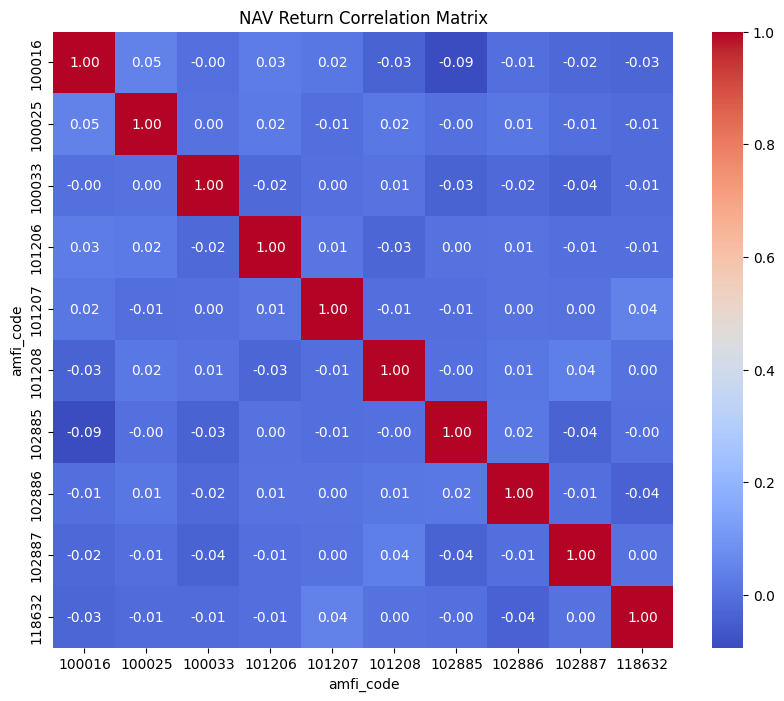

In [79]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix')
plt.show()

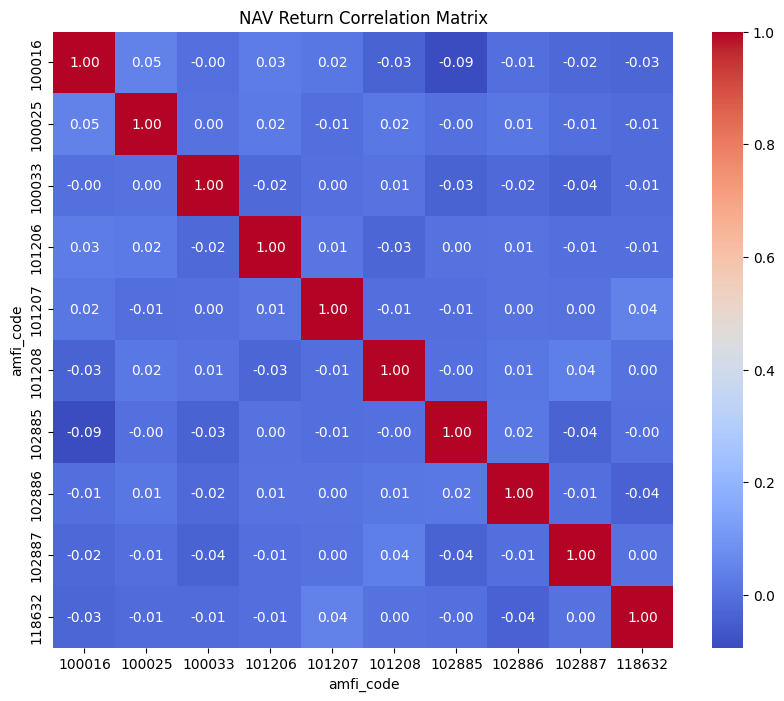

In [80]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix')

plt.savefig(
    "../reports/charts/correlation_matrix.png",
    bbox_inches='tight'
)

plt.show()

## Insight 11: NAV Return Correlation Analysis

The correlation matrix measures how similarly different mutual fund schemes move over time.

Most selected funds exhibit positive correlations, indicating that they generally respond similarly to broader market movements.

Highly correlated funds may offer limited diversification benefits, while lower-correlated funds can help investors reduce portfolio risk through diversification.

The analysis highlights the importance of combining funds with different return behaviors when constructing investment portfolios.

In [83]:
# Sector Allocation Donut Chart
portfolio_df = pd.read_csv(r"C:\Users\austi\OneDrive\Desktop\Capstone_Project\data\raw\09_portfolio_holdings.csv")

portfolio_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [84]:
portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [85]:
# Secotr Allocation Donut Chart

# Aggregate Sector weights
sector_weights = (
    portfolio_df.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)
sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [86]:
# Creating donut chart
fig = px.pie(
    values=sector_weights.values,
    names=sector_weights.index,
    hole=0.45,
    title='Sector Allocation Across Mutual Fund Portfolios'
)

fig.show()

In [87]:
fig.write_image("../reports/charts/sector_allocation_donut.png")

## Insight 12: Sector Allocation Analysis

The portfolio holdings analysis shows that investments are concentrated in a few major sectors.

Banking, Technology, Pharma, Consumer, and Industrial sectors account for a significant share of portfolio allocations across mutual fund schemes.

The sector distribution highlights diversification across industries while maintaining exposure to sectors with strong long-term growth potential.

Understanding sector allocation helps investors evaluate portfolio concentration risk and identify dominant investment themes.

In [88]:
# 13 : KYC Status Distribution
kyc_counts = trans_df['kyc_status'].value_counts()

fig = px.pie(
    values=kyc_counts.values,
    names=kyc_counts.index,
    title='KYC Status Distribution'
)

fig.show()

fig.write_image("../reports/charts/kyc_distribution.png")

## Insight 13: KYC Status Analysis

The majority of investors have completed KYC verification, indicating regulatory compliance and readiness for investment participation.

A smaller proportion of investors remain in pending status, highlighting opportunities for onboarding and compliance completion.

In [89]:
# 14 : Transaction Type distribution

transaction_counts = trans_df['transaction_type'].value_counts()

fig = px.bar(
    x=transaction_counts.index,
    y=transaction_counts.values,
    title='Transaction Type Distribution'
)

fig.show()

fig.write_image("../reports/charts/transaction_type_distribution.png")

## Insight 14: Transaction Type Analysis

SIP transactions account for a significant share of investor activity, highlighting the growing preference for systematic investing.

Lumpsum and redemption transactions contribute the remaining share, reflecting varying investor strategies and liquidity requirements.

In [90]:
# 15 : Bonus Chart 15: Fund House-wise Number of Schemes

fig = px.bar(
    aum_df,
    x='fund_house',
    y='num_schemes',
    title='Number of Schemes by Fund House'
)

fig.show()

fig.write_image("../reports/charts/fund_house_schemes.png")

## Insight 15: Fund House Scheme Analysis

Fund houses differ significantly in the number of schemes they offer.

A larger number of schemes indicates broader product diversification and greater choice for investors across asset classes and investment objectives.